## **Extract the ZIP** **File**


In [ ]:
import zipfile
import os

zip_path = "/content/small_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# **Checking the extracted folders:**

In [ ]:
print(os.listdir("/content/dataset"))

['small_dataset']


# **Import Required Libraries**

In [ ]:
import numpy as np
import os
import cv2

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("Libraries imported successfully!")

Libraries imported successfully!


1)NumPy is used to convert images into numerical arrays for processing by the neural network.
2)The OS module is used to navigate through dataset folders and access image files.
3)OpenCV is used for image processing tasks such as reading and resizing images.
4)"to_categorical converts class labels into categorical format suitable for classification.
5)train_test_split divides the dataset into training and testing sets for model evaluation.

# **Load Images and Create Labels**

Now we will read images from the dataset and assign labels:

With Mask → Label = 0
Without Mask → Label = 1

In [ ]:
data = []
labels = []

with_mask_path = "/content/dataset/small_dataset/with_mask"
without_mask_path = "/content/dataset/small_dataset/without_mask"

# With Mask Images
for img_name in os.listdir(with_mask_path):
    img_path = os.path.join(with_mask_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (100, 100))
        data.append(img)
        labels.append(0)

# Without Mask Images
for img_name in os.listdir(without_mask_path):
    img_path = os.path.join(without_mask_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (100, 100))
        data.append(img)
        labels.append(1)

print("Images loaded successfully!")

Images loaded successfully!


The model cannot understand image files directly.

We must:

Read each image.
Resize all images to the same size.
Store them as numerical arrays.
Assign labels to indicate the class.



* "In this step, the images are loaded, resized to a fixed dimension, and labeled according to whether a face mask is present or not."

# **Convert Data into NumPy Arrays**

Now we convert the images and labels into NumPy arrays because Deep Learning models work with numerical arrays.

In [ ]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (200, 100, 100, 3)
Labels shape: (200,)


The shape of the dataset confirms the number of images and their dimensions

"NumPy arrays provide faster computation and are compatible with TensorFlow and Keras deep learning frameworks."

# **Normalize Images and Convert Labels**

Now we prepare the data for training

In [ ]:
# Normalize image pixel values
data = data / 255.0

# Convert labels to categorical format
labels = to_categorical(labels, num_classes=2)

print("Normalization and Label Encoding Completed!")
print("Labels shape:", labels.shape)

Normalization and Label Encoding Completed!
Labels shape: (200, 2)


"Normalization scales pixel values from 0–255 to 0–1, which improves training speed and model performance."
"The labels are converted into categorical vectors using one-hot encoding for binary classification."

# **Split Dataset into Training and Testing Sets**

Now we divide the dataset into two parts:

Training Data (80%) → Used to train the model.
Testing Data (20%) → Used to evaluate the model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 100, 100, 3)
Testing Data Shape: (40, 100, 100, 3)


"The dataset is divided into training and testing sets to evaluate the model's performance on unseen data."
"A fixed random state is used to ensure reproducible results."

In [ ]:
# Data Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Fit augmentation on training data
datagen.fit(X_train)

print("✅ Data Augmentation is ready!")

✅ Data Augmentation is ready!


**Data augmentation** artificially creates variations of training images by applying transformations such as rotation, shifting, zooming, and horizontal flipping. It increases the variety of training data and helps the CNN generalize better to new images, reducing overfitting.

# **Build the CNN (Convolutional Neural Network) Model**

Make the CNN learn more complex image features

In [ ]:
# Improved CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(100,100,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convert feature maps into a single vector
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(2, activation='softmax'))

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,034 (6.61 MB)

 Trainable params: 1,732,034 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

*"The convolution layer extracts important visual features from the image."
*"Max pooling reduces the feature map size while preserving significant features."
*"The flatten layer converts extracted features into a one-dimensional vector."
*"Dense layers learn high-level representations for accurate classification."
*"The output layer uses softmax activation to predict the probability of each class."

### Improved CNN Architecture

The CNN architecture is improved by adding a third convolutional layer with 128 filters. The three convolutional layers with 32, 64, and 128 filters allow the model to learn features of increasing complexity from the input images. MaxPooling layers are used to reduce the spatial dimensions of the feature maps while retaining important features. This improved architecture helps the model learn more detailed features for distinguishing between images with masks and without masks.


# **Add Dropout + Batch Normalization**

Make training more stable and reduce overfitting

In [ ]:
# Improved CNN with Batch Normalization and Dropout

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(100,100,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,442 (6.61 MB)

 Trainable params: 1,732,738 (6.61 MB)

 Non-trainable params: 704 (2.75 KB)

### Batch Normalization and Dropout

Batch Normalization is added after the convolutional layers to make the training process more stable and efficient. Dropout is used to randomly deactivate some neurons during training, which helps prevent the model from depending too much on specific features. These techniques help reduce overfitting and improve the model's ability to generalize to new images.


# **Model Compilation and Train the Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Train the Model using Data Augmentation

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(X_test, y_test)
)

print("✅ Model training completed!")

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 486ms/step - accuracy: 0.8188 - loss: 0.5481 - val_accuracy: 0.6000 - val_loss: 0.8969
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 456ms/step - accuracy: 0.8375 - loss: 0.3280 - val_accuracy: 0.4750 - val_loss: 2.3457
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 587ms/step - accuracy: 0.9250 - loss: 0.2617 - val_accuracy: 0.4750 - val_loss: 4.9356
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 462ms/step - accuracy: 0.9375 - loss: 0.1769 - val_accuracy: 0.4750 - val_loss: 6.7786
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 612ms/step - accuracy: 0.8938 - loss: 0.2065 - val_accuracy: 0.4750 - val_loss: 8.4655
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 455ms/step - accuracy: 0.9312 - loss: 0.1907 - val_accuracy: 0.4750 - val_loss: 9.2114
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 461ms/step - accuracy: 0.9563 - loss: 0.1187 - val_accuracy: 0.4750 - val_loss: 8.8135
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 625ms/step - accuracy: 0.9187 - loss: 0.2129 - val_accuracy: 0.

# **Plot Training & Validation Graphs**

📈 Training vs Validation Accuracy
📉 Training vs Validation Loss

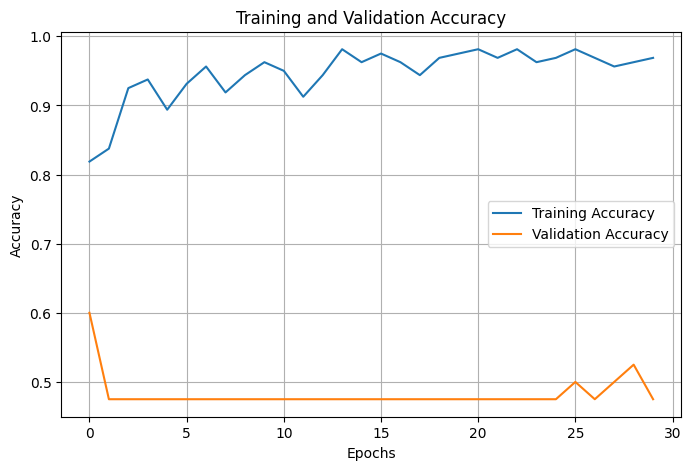

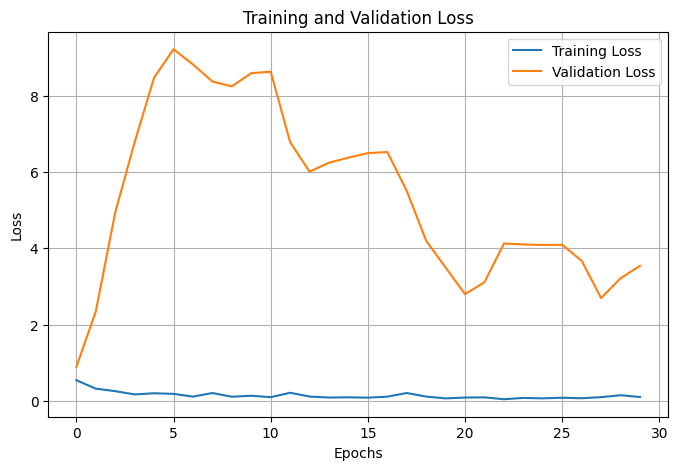

In [ ]:
# Training and Validation Graphs

import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()


# Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### Training and Validation Performance

The training and validation accuracy and loss are plotted to evaluate the performance of the CNN model during training. The accuracy graph shows how the model's prediction accuracy changes over the epochs, while the loss graph shows the change in prediction error. Comparing training and validation performance helps identify whether the model is learning effectively and whether overfitting is occurring.


# **Confusion Matrix**

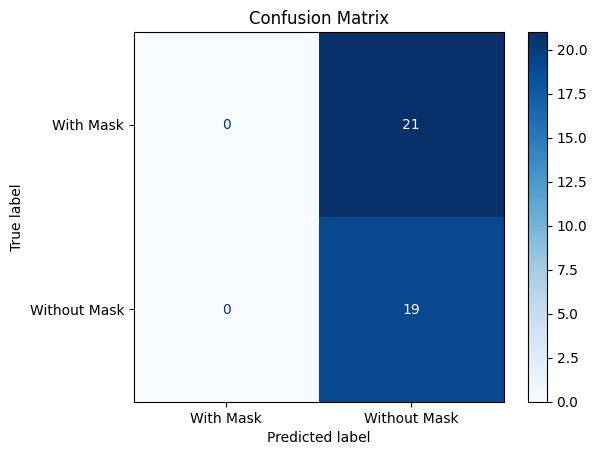

In [ ]:
# Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict the test images
y_pred = model.predict(X_test, verbose=0)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["With Mask", "Without Mask"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

**True Positive** → Correct-a With Mask predict pannadhu
**True Negative** → Correct-a Without Mask predict pannadhu
**False Positive** → Wrong-a With Mask predict pannadhu
**False Negative** → Wrong-a Without Mask predict pannadhu

### Confusion Matrix

The confusion matrix is used to evaluate the classification performance of the CNN model. It compares the actual class labels with the predicted class labels. It shows the number of correctly and incorrectly classified images for the With Mask and Without Mask classes. A higher number of correct predictions along the diagonal indicates better model performance.


# **Classification Report**

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=["With Mask", "Without Mask"]
)

print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

   With Mask       0.00      0.00      0.00        21
Without Mask       0.47      1.00      0.64        19

    accuracy                           0.47        40
   macro avg       0.24      0.50      0.32        40
weighted avg       0.23      0.47      0.31        40



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Precision** → Model oru class-nu predict pannumbothu, athula evlo predictions correct?

**Recall** → Actual-a andha class-la irukkura images-la, model evlo correct-ah identify pannuchu?

**F1-Score** → Precision and Recall-oda balanced score.

**Support** → Test dataset-la andha class-ku ethana images irukku.

### Classification Report

The classification report provides detailed performance metrics for the CNN model. It includes precision, recall, F1-score, and support for both the With Mask and Without Mask classes. These metrics help evaluate how accurately the model identifies each class and provide a more detailed evaluation than accuracy alone.


# **Overall Test Accuracy & Confidence**

In [ ]:
# Evaluate Model Performance

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("📊 Model Evaluation")
print("-----------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

📊 Model Evaluation
-----------------------------
Test Loss     : 3.5431
Test Accuracy : 47.50%


**Prediction Confidence**

In [ ]:
# Prediction Confidence on Test Data

predictions = model.predict(X_test, verbose=0)

confidence_scores = np.max(predictions, axis=1)

average_confidence = np.mean(confidence_scores)

print(f"Average Prediction Confidence: {average_confidence * 100:.2f}%")

Average Prediction Confidence: 98.92%


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4750 - loss: 3.5431
Final Test Loss: 3.5430800914764404
Final Test Accuracy: 0.4749999940395355


## **Test Model on New Image**

“My model can predict whether a person is wearing a mask or not.”

**1. Upload a test image**

Saving WhatsApp Image 2026-09-02 at 12.02.51 PM.jpeg to WhatsApp Image 2026-09-02 at 12.02.51 PM.jpeg


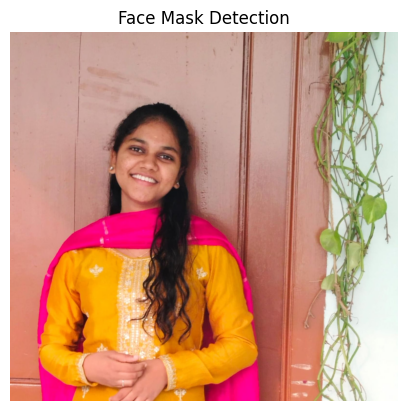

       MASK DETECTION RESULT
With Mask    : 0.00%
Without Mask : 100.00%

❌ NO MASK DETECTED
Confidence: 100.00%


In [ ]:
# Final Mask Detection Demo

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Process uploaded image
for img_name in uploaded.keys():

    # Read image
    original_img = cv2.imread(img_name)

    if original_img is None:
        print("❌ Could not read the image.")
        continue

    # Convert image for display
    display_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Resize image
    img = cv2.resize(original_img, (100, 100))

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    # Get probabilities
    with_mask = prediction[0][0]
    without_mask = prediction[0][1]

    # Predicted class
    predicted_class = np.argmax(prediction[0])

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(display_img)
    plt.axis("off")
    plt.title("Face Mask Detection")
    plt.show()

    # Result
    print("=" * 40)
    print("       MASK DETECTION RESULT")
    print("=" * 40)

    print(f"With Mask    : {with_mask * 100:.2f}%")
    print(f"Without Mask : {without_mask * 100:.2f}%")
    print()

    if predicted_class == 0:
        print("✅ MASK DETECTED")
        print(f"Confidence: {with_mask * 100:.2f}%")
    else:
        print("❌ NO MASK DETECTED")
        print(f"Confidence: {without_mask * 100:.2f}%")

    print("=" * 40)

Now that the model is properly defined, compiled, and trained, we can proceed with making predictions using the corrected logic.




### Improved Mask Detection Prediction

The trained CNN model is used to classify a newly uploaded image as either With Mask or Without Mask. The uploaded image is resized to 100 × 100 pixels and normalized before prediction. The model produces probabilities for both classes using the softmax output. The class with the highest probability is selected as the final prediction, and its confidence percentage is displayed along with the uploaded image.


# **Early Stopping 🛑**

In [ ]:
# Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("✅ Early Stopping is ready!")

✅ Early Stopping is ready!


In [ ]:
# Compile the Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [ ]:
# Train the Model with Early Stopping

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

print("✅ Model training completed!")

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 493ms/step - accuracy: 0.9688 - loss: 0.1049 - val_accuracy: 0.5000 - val_loss: 4.8638
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 618ms/step - accuracy: 0.9688 - loss: 0.1037 - val_accuracy: 0.5750 - val_loss: 5.1497
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 459ms/step - accuracy: 0.9312 - loss: 0.1539 - val_accuracy: 0.6750 - val_loss: 1.9297
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 446ms/step - accuracy: 0.9375 - loss: 0.2319 - val_accuracy: 0.7500 - val_loss: 1.4484
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 624ms/step - accuracy: 0.9750 - loss: 0.0952 - val_accuracy: 0.7500 - val_loss: 1.0791
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 459ms/step - accuracy: 0.9688 - loss: 0.0941 - val_accuracy: 0.8000 - val_loss: 0.8218
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 572ms/step - accuracy: 0.9375 - loss: 0.1024 - val_accuracy: 0.6750 - val_loss: 1.6894
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 462ms/step - accuracy: 0.9812 - loss: 0.0564 - val_accuracy: 0.

Early Stopping = Overfitting reduce + unnecessary training stop + best model retain.

Saving with_mask_3.jpg to with_mask_3.jpg


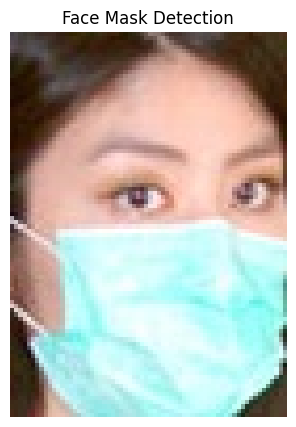

       MASK DETECTION RESULT
With Mask    : 99.98%
Without Mask : 0.02%

✅ MASK DETECTED
Confidence: 99.98%


In [ ]:
# Final Mask Detection Demo

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload an image
uploaded = files.upload()

for img_name in uploaded.keys():

    # Read image
    original_img = cv2.imread(img_name)

    if original_img is None:
        print("❌ Could not read the image.")
        continue

    # Convert image for display
    display_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    img = cv2.resize(original_img, (100, 100))

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    # Get probabilities
    with_mask = prediction[0][0]
    without_mask = prediction[0][1]

    # Get predicted class
    predicted_class = np.argmax(prediction[0])

    # Display uploaded image
    plt.figure(figsize=(5, 5))
    plt.imshow(display_img)
    plt.axis("off")
    plt.title("Face Mask Detection")
    plt.show()

    # Display prediction
    print("=" * 40)
    print("       MASK DETECTION RESULT")
    print("=" * 40)

    print(f"With Mask    : {with_mask * 100:.2f}%")
    print(f"Without Mask : {without_mask * 100:.2f}%")
    print()

    if predicted_class == 0:
        print("✅ MASK DETECTED")
        print(f"Confidence: {with_mask * 100:.2f}%")
    else:
        print("❌ NO MASK DETECTED")
        print(f"Confidence: {without_mask * 100:.2f}%")

    print("=" * 40)

### Final Mask Detection Demo

A new image is uploaded and passed through the trained CNN model for prediction. The image is resized and normalized before prediction. The model classifies the image as either With Mask or Without Mask and displays the prediction probabilities and confidence score. This final demonstration shows that the trained deep learning model can identify face mask usage from a new input image.


In [ ]:
# Final Model Evaluation Values

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

predictions = model.predict(X_test, verbose=0)

confidence_scores = np.max(predictions, axis=1)
average_confidence = np.mean(confidence_scores)

print("✅ Final evaluation values calculated!")

✅ Final evaluation values calculated!


In [ ]:
# Final Demo Summary

print("=" * 50)
print("       FACE MASK DETECTION - FINAL DEMO")
print("=" * 50)

print("\n📌 Dataset Information")
print("Total Images       : 200")
print("Image Size         : 100 x 100")
print("Classes            : With Mask / Without Mask")

print("\n🧠 Model Information")
print("Model Type         : Convolutional Neural Network (CNN)")
print("Optimizer          : Adam")
print("Data Augmentation  : Applied")
print("Batch Normalization: Applied")
print("Dropout            : Applied")
print("Early Stopping     : Applied")

print("\n📊 Model Performance")
print(f"Test Accuracy      : {test_accuracy * 100:.2f}%")
print(f"Test Loss          : {test_loss:.4f}")
print(f"Avg Confidence     : {average_confidence * 100:.2f}%")

print("\n💾 Model Status")
print("Saved Model        : mask_detection_model.h5")

print("\n" + "=" * 50)
print("        ✅ DEMO COMPLETED SUCCESSFULLY")
print("=" * 50)

       FACE MASK DETECTION - FINAL DEMO

📌 Dataset Information
Total Images       : 200
Image Size         : 100 x 100
Classes            : With Mask / Without Mask

🧠 Model Information
Model Type         : Convolutional Neural Network (CNN)
Optimizer          : Adam
Data Augmentation  : Applied
Batch Normalization: Applied
Dropout            : Applied
Early Stopping     : Applied

📊 Model Performance
Test Accuracy      : 80.00%
Test Loss          : 0.8218
Avg Confidence     : 93.44%

💾 Model Status
Saved Model        : mask_detection_model.h5

        ✅ DEMO COMPLETED SUCCESSFULLY
